# Iniciando o Pojeto de NLP da Semana 5, 6 e 7

- Fazendo os imports necessarios

In [80]:
#!pip install seaborn numpy scikit-learn pandas matplotlib #deve ser rodado na primeira vez

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

- Começando a configuraçao inicial

In [ ]:
# Iniciando a configuraçao


# Carregamento paras as variaveis de treinamento e teste fazendo a remoçao de ruidos

categorias = ['alt.atheism', 'soc.religion.christian', 'comp.graphics', 'sci.med']
train_data = fetch_20newsgroups(subset='train', categories=categorias, remove=('headers', 'footers', 'quotes'))
test_data = fetch_20newsgroups(subset='test', categories=categorias, remove=('headers', 'footers', 'quotes'))


# Vectorizaçao Deixando mais Honesta

vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    ngram_range=(1, 2),  # ngrama ajuda na interpretaçao de palavras conjuntas
    max_df=0.9,          # Ignora possiveis palavras muito comuns
    min_df=3,            # Retira as palavras que sao raras
    max_features=10000   # Utilizado para limitar às melhores partes
)

X_train = vectorizer.fit_transform(train_data.data)
X_test = vectorizer.transform(test_data.data)
y_train = train_data.target
y_test = test_data.target

- Iniciando a parte de Vetorização

In [ ]:
# Organizando os modelos em um dicionario para fazer a comparaçao

modelos = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVC": LinearSVC(dual=False, C=1.0)
}

scores = {} #lista para armazenar os scores


#fazendo um treinamento para comparar os modelos

for nome, model in modelos.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    scores[nome] = acc


- Plotando um grafico de barras para ver a accuracia

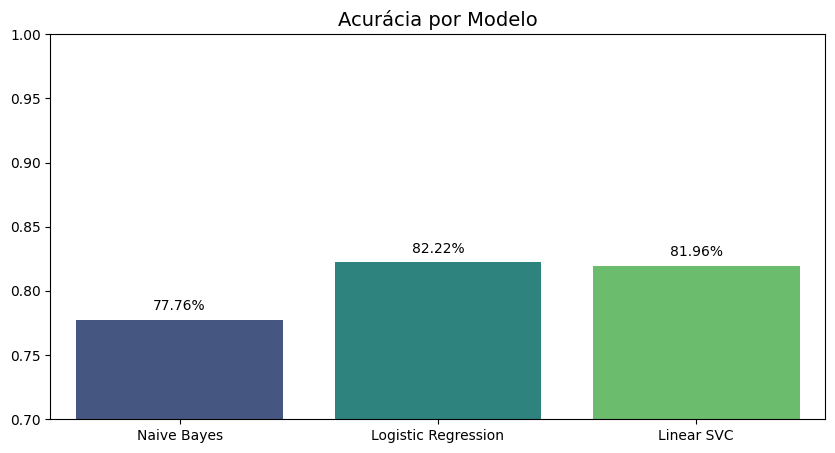

In [90]:
# Preparando o gráfico para visualizar a acurácia
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    x=list(scores.keys()),
    y=list(scores.values()),
    hue=list(scores.keys()),   # para organizar o palette
    palette='viridis',
    legend=False               # evita legenda dupla
)

plt.title('Acurácia por Modelo', fontsize=14)
plt.ylim(0.7, 1.0)

# Adicionando valores nas barras
for barra in ax.patches:
    ax.annotate(
        f'{barra.get_height():.2%}',
        (barra.get_x() + barra.get_width() / 2., barra.get_height()),
        ha='center',
        va='center',
        xytext=(0, 10),
        textcoords='offset points'
    )

plt.show()

- Etapa de classificação e Avaliação

In [84]:
# Escolhendo o melhor dos modelos

melhor = max(scores, key = scores.get)
melhor_modelo = modelos[melhor]

#modell = MultinomialNB()
#modell.fit(X_train, y_train)

y_pred_melhor = melhor_modelo.predict(X_test)

print(f"\n Melhor Modelo Encontrado: {melhor}")
print("-" * 64)
print(classification_report(y_test, y_pred_melhor, target_names=categorias))


 Melhor Modelo Encontrado: Logistic Regression
----------------------------------------------------------------
                        precision    recall  f1-score   support

           alt.atheism       0.78      0.58      0.67       319
soc.religion.christian       0.89      0.92      0.91       389
         comp.graphics       0.81      0.89      0.85       396
               sci.med       0.79      0.84      0.82       398

              accuracy                           0.82      1502
             macro avg       0.82      0.81      0.81      1502
          weighted avg       0.82      0.82      0.82      1502



- Plotagem da matriz de confusao

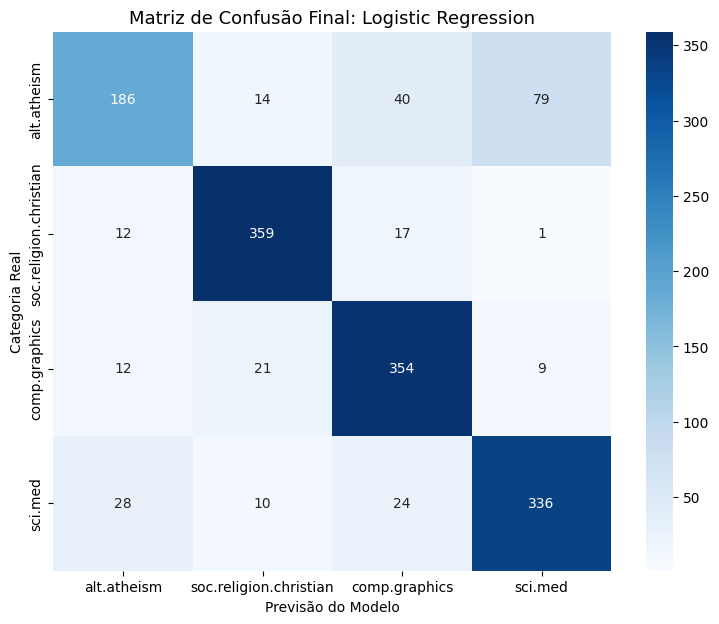

In [85]:

# Matriz de Confusao Visual
plt.figure(figsize=(9, 7))
cm = confusion_matrix(y_test, y_pred_melhor)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=categorias, yticklabels=categorias)
plt.title(f'Matriz de Confusão Final: {melhor}', fontsize=13)
plt.ylabel('Categoria Real')
plt.xlabel('Previsão do Modelo')
plt.show()

- Fazendo uma breve analise dos resultados

In [87]:
df_resultados = pd.DataFrame({
    "Texto": test_data.data,
    "Real": [categorias[i] for i in y_test],
    "Previsao": [categorias[i] for i in y_pred_melhor]  # usando o melhor modelo
})

# pegando apenas os erros
erros = df_resultados.query("Real != Previsao").copy()

total_erros = len(erros)
total_amostras = len(df_resultados)

print(f"\nO modelo errou {total_erros} de {total_amostras} amostras "
      f"({total_erros/total_amostras:.2%}).")

print("\n Exemplos de erros :")


display(erros.head(10))


O modelo errou 267 de 1502 amostras (17.78%).

 Exemplos de erros :


,Texto,Real,Previsao
12,I heard a great Civil War story... A guy ...,comp.graphics,sci.med
15,[This is SWF in another indirect post via Dan]...,alt.atheism,comp.graphics
19,"As requested, here are some addresses of sourc...",alt.atheism,sci.med
26,"Hello,\n \nI've been on the DKBtrace/PoVray ma...",soc.religion.christian,alt.atheism
32,"\n\n\n\nSure, a person could have great respec...",alt.atheism,sci.med
35,: >\n: >I think you're letting atheist mytholo...,alt.atheism,sci.med
38,\nI don't believe any state licenses herbologi...,comp.graphics,alt.atheism
48,"...\n\n\nI'm in Japan.\n(Michael, could you gi...",sci.med,soc.religion.christian
52,\n...\n...\n\n\nI can think of another alterna...,sci.med,alt.atheism
55,[This was crossposted to a zillion groups. I ...,sci.med,alt.atheism
